# Level 3 — Imaging-Based Spatial: Xenium Organoids

## CAJAL "Neuromics 2026" — Computational Mini-Project C10 (Level 3)

**Estimated time:** ~1.5 days

**Learning objectives**
- Load and QC single-cell-resolution Xenium imaging-based spatial transcriptomics data
- Apply the same malignant cell-state axis used in Levels 1-2 to a *third* modality, and
  sanity-check it against an existing label-transfer result
- Compare malignant-state composition across snRNA-seq (Level 1), Visium (Level 2), and
  Xenium (this notebook)
- Understand and quantify **transcript spillover/diffusion**, a real artifact of
  imaging-based spatial transcriptomics, using the nuclear-vs-cytoplasmic transcript
  location recorded by the Xenium pipeline itself

**Dataset:** Three Xenium sections from patient-derived glioblastoma organoids
(donor/line `AT410`), profiled on a 5,101-gene panel.

> ⚠️ **Data provenance note.** These samples are **not** part of the GBM-Space paper
> (de Jong, Memi, Gracia, Lazareva et al., bioRxiv 2025.05.13.653495) that Levels 1-2 are
> built around. A full-text search of the paper, both supplements, and all 14
> supplementary tables turns up no `AT410`, no `organoid`/`ORG`, no `MOI`, and a different
> Xenium gene panel (the paper's Xenium cohort is patients AT3-AT15 on a 328-gene panel,
> e.g. sample IDs like `AT10-BRA-5-FO-1-S41-ii`). These organoid samples come from a
> separate, newer experiment (organoid culture, apparently with some kind of viral
> treatment given the `MOI` — multiplicity of infection — in the sample names, sampled at
> day 7 and day 14). The `predictions` column already present in these files *does* carry
> the paper's 9 malignant-state labels, so someone has already applied that paper's
> classifier to these cells — but the biological experiment itself is unrelated to the
> publication. We treat that openly here: real datasets often arrive with partial,
> reused, or unclear provenance, and knowing what you *can't* claim about a dataset is as
> important as the analysis itself.

---

## 0. Setup

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.neighbors import NearestNeighbors

sys.path.insert(0, "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/src")
from gbmspace_utils.analysis import (
    MALIGNANT_AXIS_MARKERS, MAJOR_CLASS_OF, ZONATION_PANEL, score_axis,
    assign_dominant_state,
)
from gbmspace_utils.plotting import plot_gene_on_tissue, plot_spatial_categories

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
%matplotlib inline

print("scanpy", sc.__version__, "| pandas", pd.__version__)

<cell 2>:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
scanpy 1.11.5 | pandas 2.3.3


## 1. Load the three Xenium organoid sections

🔬 **TASK 1.1:** Load all three `_annotated.h5ad` files, tag each with a `sample` label,
and concatenate into a single object.

In [4]:
XENIUM_DIR = Path("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/xenium")

SAMPLES = {
    "D7_S28_B1_E30":  XENIUM_DIR / "AT410-BRA-5-ORG-E30-MOI0_25-D7-S28-B1_GSO1_annotated.h5ad",
    "D7_S23_B1_e25":  XENIUM_DIR / "AT410-BRA-5-ORG-e25-MOI0_25-D7-S23-B1_GSO1_annotated.h5ad",
    "D14_S73_D2_e25": XENIUM_DIR / "AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2_GSO1_annotated.h5ad",
}

# Raw Xenium Ranger output, needed later for the transcript-level spillover analysis
RAW_DIRS = {
    "D7_S28_B1_E30":  XENIUM_DIR / "output-XETG00272__0082677__AT410-BRA-5-ORG-E30-MOI0_25-D7-S28-B1__20260311__143535",
    "D7_S23_B1_e25":  XENIUM_DIR / "output-XETG00335__0082831__AT410-BRA-5-ORG-e25-MOI0_25-D7-S23-B1__20260311__143630",
    "D14_S73_D2_e25": XENIUM_DIR / "output-XETG00155__0097120__AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2__20260318__141335",
}

adatas = {}
for name, path in SAMPLES.items():
    a = sc.read_h5ad(path)
    a.obs["sample"] = name
    a.obs["day"] = "D14" if "D14" in name else "D7"
    adatas[name] = a
    print(f"{name}: {a.n_obs:>6} cells x {a.n_vars} genes")

adata = ad.concat(adatas.values(), label="sample_batch", keys=list(adatas.keys()),
                   join="outer", index_unique="-")
adata.obs["sample"] = pd.Categorical(adata.obs["sample"], categories=list(SAMPLES))
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

print(f"\nCombined: {adata.n_obs} cells x {adata.n_vars} genes")
print(adata.obs[["sample", "day"]].value_counts())

D7_S28_B1_E30:  10447 cells x 5101 genes
D7_S23_B1_e25:  21154 cells x 5101 genes
D14_S73_D2_e25:  18994 cells x 5101 genes

Combined: 50595 cells x 5101 genes
sample          day
D7_S23_B1_e25   D7     21154
D14_S73_D2_e25  D14    18994
D7_S28_B1_E30   D7     10447
Name: count, dtype: int64


❓ **QUESTION:** Two of the three samples are day 7, one is day 14, and the day-7
samples differ in an `E30`/`e25` suffix we can't confidently decode from the data alone.
Given the provenance note above, which comparisons in this notebook can we make with
confidence (e.g. day 7 vs day 14), and which would require metadata we don't have (e.g.
the biological meaning of `E30` vs `e25`)?

## 2. Quality control

🔬 **TASK 2.1:** Inspect the per-cell QC metrics already computed in the Xenium Ranger
output (`transcript_counts`, `n_genes_by_counts`, `cell_area`, `nucleus_area`,
`nucleus_ratio`), and confirm the expression matrix is already filtered and normalized.

X dtype: float32 | X max: 7.890865325927734 | X min: 0.0
Non-integer values at this scale indicate the matrix is already log1p-normalized.


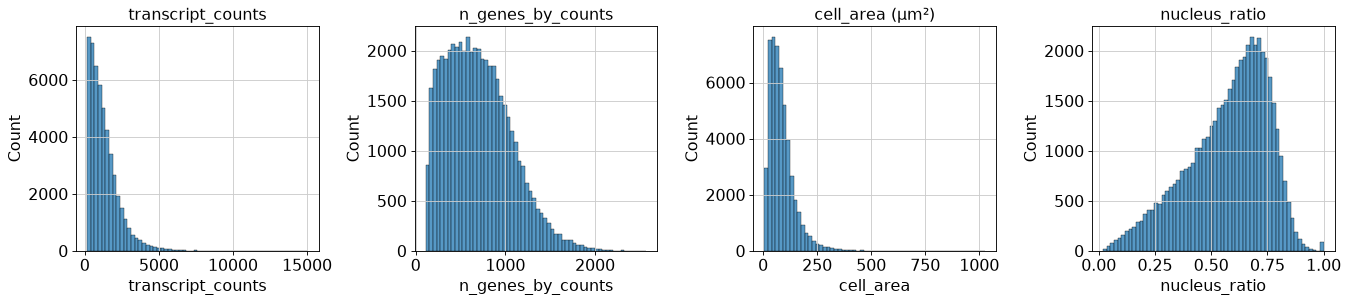

In [7]:
print("X dtype:", adata.X.dtype, "| X max:", float(adata.X.max()), "| X min:", float(adata.X.min()))
print("Non-integer values at this scale indicate the matrix is already log1p-normalized.")

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
sns.histplot(adata.obs["transcript_counts"], bins=60, ax=axes[0]); axes[0].set_title("transcript_counts")
sns.histplot(adata.obs["n_genes_by_counts"], bins=60, ax=axes[1]); axes[1].set_title("n_genes_by_counts")
sns.histplot(adata.obs["cell_area"], bins=60, ax=axes[2]); axes[2].set_title("cell_area (µm²)")
sns.histplot(adata.obs["nucleus_ratio"].dropna(), bins=60, ax=axes[3]); axes[3].set_title("nucleus_ratio")
plt.tight_layout()
plt.show()

💡 **HINT.** The paper's Methods (for its own, separate Xenium cohort) describe the
standard QC used for Xenium data: drop cells with total gene count < 10, drop genes
detected in < 10 cells, then `normalize_total` + `log1p`. The histograms above should
already look consistent with that having been applied — there's no long left tail of
near-empty cells.

⚠️ **CHECKPOINT:** All three samples should show `n_genes_by_counts` distributions with a
clear mode well above 0, and `nucleus_ratio` mostly between roughly 0.1 and 0.6 (a healthy
mix of cells with a fraction of their area being nucleus, not all-nucleus or all-cytoplasm
segmentations).

## 3. Clustering

🔬 **TASK 3.1:** Run a standard PCA → neighbors → Leiden → UMAP pipeline, and compare your
own unsupervised clusters against the `predictions` column already present in the data
(the paper's malignant-state classifier, pre-applied by whoever produced these files).

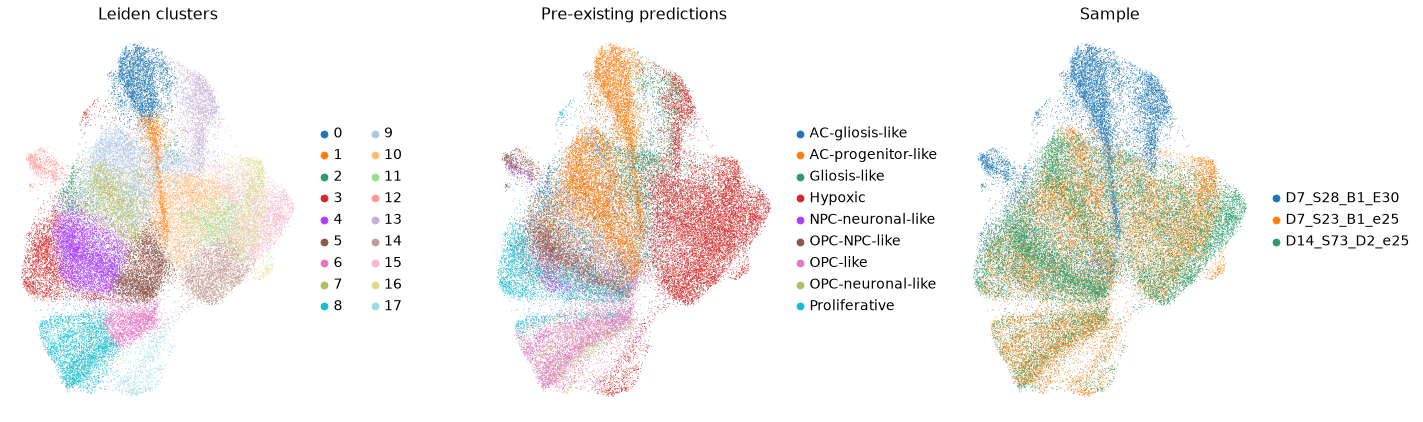

In [10]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
sc.tl.umap(adata)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden clusters")
sc.pl.umap(adata, color="predictions", ax=axes[1], show=False, title="Pre-existing predictions")
sc.pl.umap(adata, color="sample", ax=axes[2], show=False, title="Sample")
plt.tight_layout()
plt.show()

In [11]:
pd.crosstab(adata.obs["leiden"], adata.obs["predictions"])

❓ **QUESTION:** Do Leiden clusters mostly map to a single `predictions` label each,
or is there a lot of mixing? What would each pattern imply about whether transcriptional
clusters and the malignant-state axis are capturing the same axis of variation?

## 4. Cell typing via the malignant-state axis

🔬 **TASK 4.1:** Apply the *same* marker-based scoring used in Levels 1-2 — score every
cell against `MALIGNANT_AXIS_MARKERS`, then take the dominant state per cell — and compare
it to the pre-existing `predictions` column.

In [14]:
state_scores = score_axis(adata, MALIGNANT_AXIS_MARKERS, use_raw=False)
adata.obs["malignant_state"] = assign_dominant_state(state_scores)
adata.obs["malignant_class"] = adata.obs["malignant_state"].map(MAJOR_CLASS_OF)

print(adata.obs["malignant_state"].value_counts())

[score_axis] AC-progenitor-like: missing ['ALDH1L1'], using ['SLC1A3', 'GFAP', 'EGFR', 'AQP4']
[score_axis] Hypoxic: missing ['BNIP3L', 'FOS', 'HSPA1B'], using ['HILPDA', 'VEGFA', 'JUN']
[score_axis] Proliferative: missing ['DLGAP5', 'CKAP2L', 'CDCA8'], using ['CDCA2', 'CDC25C', 'TTK', 'BUB1', 'HMMR', 'TOP2A', 'MKI67', 'BIRC5', 'CDK1']
malignant_state
AC-progenitor-like    21711
Hypoxic               12893
OPC-like               4166
OPC-NPC-like           2558
NPC-neuronal-like      2450
Gliosis-like           2275
Proliferative          1934
AC-gliosis-like        1754
OPC-neuronal-like       854
Name: count, dtype: int64


In [15]:
concordance = pd.crosstab(adata.obs["malignant_state"], adata.obs["predictions"], normalize="index")
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(concordance, cmap="viridis", annot=False, ax=ax)
ax.set_title("Row-normalized agreement: our score_axis call vs. existing `predictions`")
plt.tight_layout()

agree_frac = (adata.obs["malignant_state"] == adata.obs["predictions"]).mean()
print(f"Exact same dominant label for {agree_frac:.1%} of cells")

Exact same dominant label for 54.2% of cells


💡 **HINT.** Don't expect perfect diagonal agreement — `predictions` was produced by
a different pipeline (likely Tangram-based label transfer from a patient-matched snRNA-seq
reference, per the paper's Methods), while `score_axis` is a simple marker-score argmax.
Substantial off-diagonal mass concentrated *within* the same major class (e.g. confusing
`AC-gliosis-like` with `Gliosis-like`) is a healthy sign; mass scattered with no structure
at all would be a red flag.

⚠️ **CHECKPOINT:** Exact-label agreement in the 30-60% range, concentrated along the
major-class block-diagonal in the heatmap, is the expected outcome for two independently
derived state calls on the same axis — re-examine `MALIGNANT_AXIS_MARKERS` coverage in this
5,101-gene panel if agreement looks closer to random.

## 5. Spatial visualization

🔬 **TASK 5.1:** Map the malignant-state axis onto each tissue section, and look at the
`ZONATION_PANEL` genes directly on tissue (same as Level 2's first look at spatial
structure, before any deconvolution).

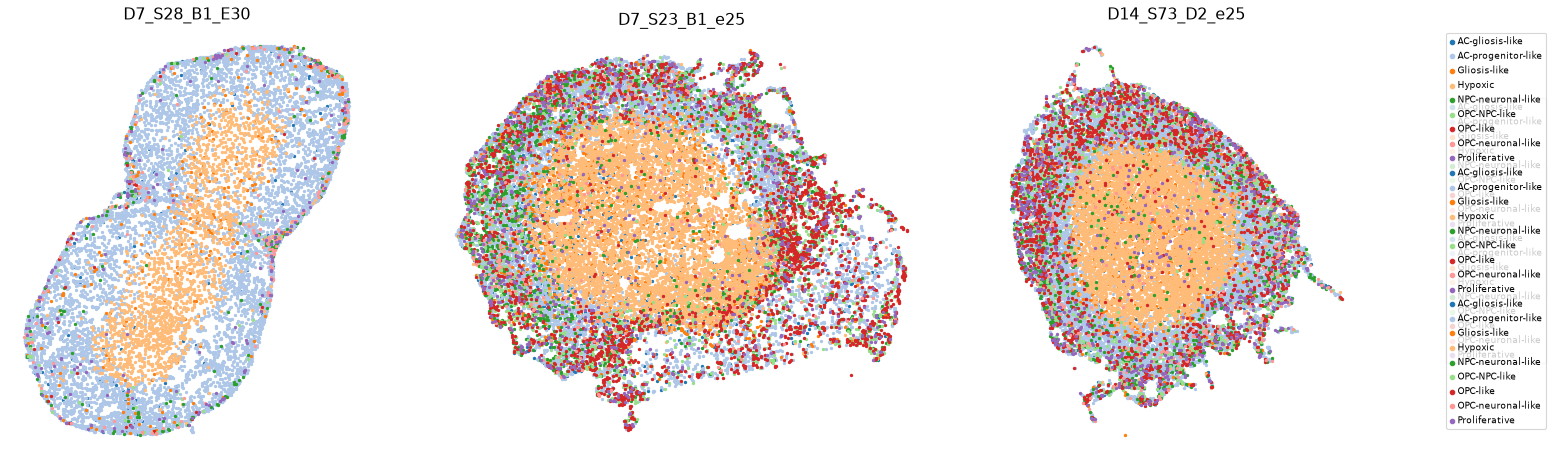

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, name in zip(axes, SAMPLES):
    sub = adata[adata.obs["sample"] == name].copy()
    plot_spatial_categories(sub, "malignant_state", ax=ax, point_size=4.0)
    ax.set_title(name)
plt.tight_layout()
plt.show()

ZONATION_PANEL genes present in this 5,101-gene panel: ['AQP4', 'ABCC3', 'AKAP12', 'HILPDA']


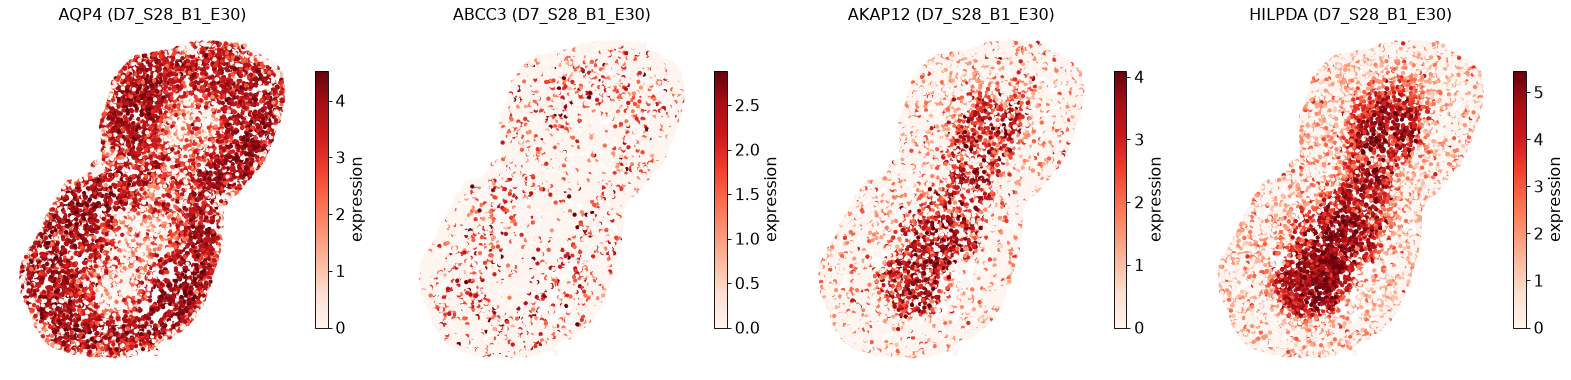

In [19]:
present_zonation = [g for g in ZONATION_PANEL if g in adata.var_names]
print("ZONATION_PANEL genes present in this 5,101-gene panel:", present_zonation)

fig, axes = plt.subplots(1, len(present_zonation), figsize=(5 * len(present_zonation), 5))
ref_sample = "D7_S28_B1_E30"
sub = adata[adata.obs["sample"] == ref_sample].copy()
for ax, gene in zip(np.atleast_1d(axes), present_zonation):
    plot_gene_on_tissue(sub, gene, ax=ax)
    ax.set_title(f"{gene} ({ref_sample})")
plt.tight_layout()
plt.show()

❓ **QUESTION:** Levels 1-2 found a clear `AQP4 → ABCC3 → AKAP12 → HILPDA` spatial
gradient in real tumour tissue, reflecting a gradient from vascularized tissue to
hypoxic/necrotic core. Do you see anything resembling that gradient here? What
structural feature of an *organoid* (vs. an orthotopic tumour) would you expect to change
this — organoids grown in culture generally lack the mature, irregular vasculature that
drives that gradient in vivo.

## 6. Cross-modality comparison: snRNA-seq vs. Visium vs. Xenium

🔬 **TASK 6.1:** Compare the malignant-state-axis composition seen here against Level 1
(snRNA-seq nuclei) and Level 2 (Visium spots, scored the same simple marker-score way,
independent of cell2location). This is **not** a matched same-patient comparison — Level
1/2 are real tumour tissue from patients AT10/AT14, and this notebook's data is a
patient-derived organoid line (AT410) — so frame it as: *does the malignant-state axis
discovered in real tumours still organize variation in an organoid model?*

In [22]:
# Level 1: snRNA-seq, already annotated with malignant_state in Step 3
l1 = sc.read_h5ad(
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/data/processed/gbm_l1_snrna_AT10_AT14_annotated.h5ad",
    backed="r",
)
l1_state = l1.obs["malignant_state"].value_counts(normalize=True).rename("snRNA-seq (AT10+AT14)")

# Level 2: Visium, scored the same simple marker-score way (independent of cell2location,
# so this doesn't need to wait on Level 2's full deconvolution run)
visium_paths = {
    "Visium AT10": "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/visium/level2_prepared/AT10-BRA-5-FO-1_2_student.h5ad",
    "Visium AT14": "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/visium/level2_prepared/AT14-BRA-4-FO-2_1_student.h5ad",
}
visium_states = {}
for label, p in visium_paths.items():
    v = sc.read_h5ad(p)
    v = v[:, v.var.get("feature_types", "Gene Expression").isin(["Gene Expression"]) if "feature_types" in v.var else slice(None)].copy()
    sc.pp.normalize_total(v, target_sum=1e4)
    sc.pp.log1p(v)
    vs = score_axis(v, MALIGNANT_AXIS_MARKERS, use_raw=False)
    visium_states[label] = assign_dominant_state(vs).value_counts(normalize=True)

xenium_state = adata.obs["malignant_state"].value_counts(normalize=True).rename("Xenium organoid (AT410)")

comparison = pd.concat([l1_state, *[s.rename(k) for k, s in visium_states.items()], xenium_state], axis=1).fillna(0.0)
comparison = comparison.reindex(MALIGNANT_AXIS_MARKERS.keys())
comparison

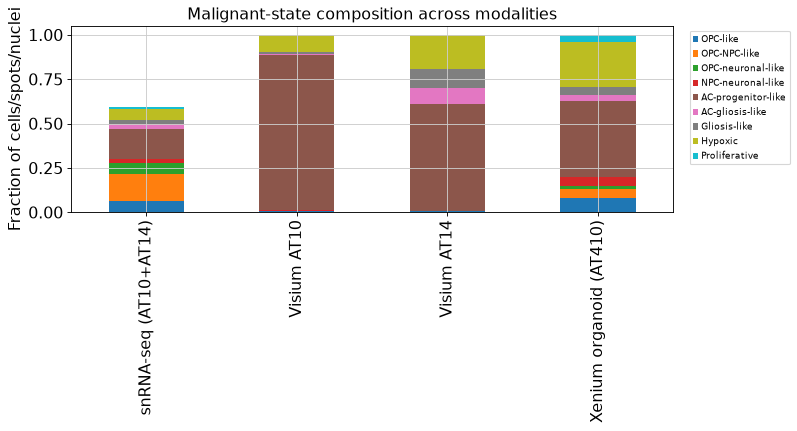

In [23]:
fig, ax = plt.subplots(figsize=(10, 5.5))
comparison.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Fraction of cells/spots/nuclei")
ax.set_title("Malignant-state composition across modalities")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

💡 **HINT.** Real tumours retain TME (immune/vascular/stromal) cells that real
organoid cultures of this kind typically lack almost entirely (no blood supply, no
peripheral immune infiltration) — Level 1's `malignant_state` includes a large `TME`
bucket that has no organoid counterpart; exclude it before comparing proportions among
malignant states only if you want a cleaner like-for-like comparison.

❓ **QUESTION:** Which malignant states are over- or under-represented in the organoid
relative to real tumour tissue? Hypoxic/Gliosis-like states are typically driven by poor
oxygen/nutrient diffusion in a growing mass — does the organoid's size and culture
condition make you expect more or less of those states than an in vivo tumour?

## 7. Nuclear vs. cytoplasmic transcript spillover

Xenium (and other imaging-based SRT platforms) assign each detected transcript to the
nearest cell based on its image-derived boundary. A transcript synthesised inside one
cell can easily be detected a few microns away, inside a *neighbouring* cell's boundary —
this is **transcript spillover/diffusion**, and it's exactly the problem BASIS (the next
notebook) is built to address. The raw Xenium output records, for every single detected
transcript, whether it physically overlapped the assigned cell's nucleus
(`overlaps_nucleus`) — giving us a direct, per-transcript window into this.

🔬 **TASK 7.1:** Load the per-transcript table for all three samples (filtering to
high-confidence, gene-targeting, assigned transcripts), and compute each cell's nuclear
vs. cytoplasmic transcript fraction.

In [26]:
QV_CUTOFF = 20.0  # Xenium's own recommended confidence threshold

spillover_frames = []
for name, d in RAW_DIRS.items():
    tx = pq.read_table(
        d / "transcripts.parquet",
        columns=["cell_id", "overlaps_nucleus", "feature_name", "qv", "is_gene", "nucleus_distance"],
        filters=[("is_gene", "=", True), ("qv", ">=", QV_CUTOFF)],
    ).to_pandas()
    tx = tx[tx["cell_id"] != "UNASSIGNED"]
    tx["sample"] = name
    spillover_frames.append(tx)
    print(f"{name}: {len(tx):>10,} assigned, qv>={QV_CUTOFF:.0f}, gene-targeting transcripts")

transcripts = pd.concat(spillover_frames, ignore_index=True)
print(f"\nTotal: {len(transcripts):,} transcripts across all 3 samples")

D7_S28_B1_E30: 31,845,933 assigned, qv>=20, gene-targeting transcripts
D7_S23_B1_e25: 58,098,427 assigned, qv>=20, gene-targeting transcripts
D14_S73_D2_e25: 28,066,239 assigned, qv>=20, gene-targeting transcripts

Total: 118,010,599 transcripts across all 3 samples


In [27]:
per_cell = (
    transcripts.groupby(["sample", "cell_id"])
    .agg(n_transcripts=("overlaps_nucleus", "size"), n_nuclear=("overlaps_nucleus", "sum"))
    .reset_index()
)
per_cell["nuclear_fraction"] = per_cell["n_nuclear"] / per_cell["n_transcripts"]

key = adata.obs["sample"].astype(str) + "::" + adata.obs["cell_id"].astype(str)
lookup = per_cell.set_index(per_cell["sample"].astype(str) + "::" + per_cell["cell_id"].astype(str))
adata.obs["n_transcripts_checked"] = key.map(lookup["n_transcripts"]).to_numpy()
adata.obs["nuclear_fraction"] = key.map(lookup["nuclear_fraction"]).to_numpy()

print(adata.obs["nuclear_fraction"].describe())

count    50595.000000
mean         0.648968
std          0.187865
min          0.000000
25%          0.543889
50%          0.696000
75%          0.790668
max          1.000000
Name: nuclear_fraction, dtype: float64


🔬 **TASK 7.2:** Relate the per-cell nuclear fraction to cell morphology
(`nucleus_ratio`) and to malignant state.

<cell 29>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


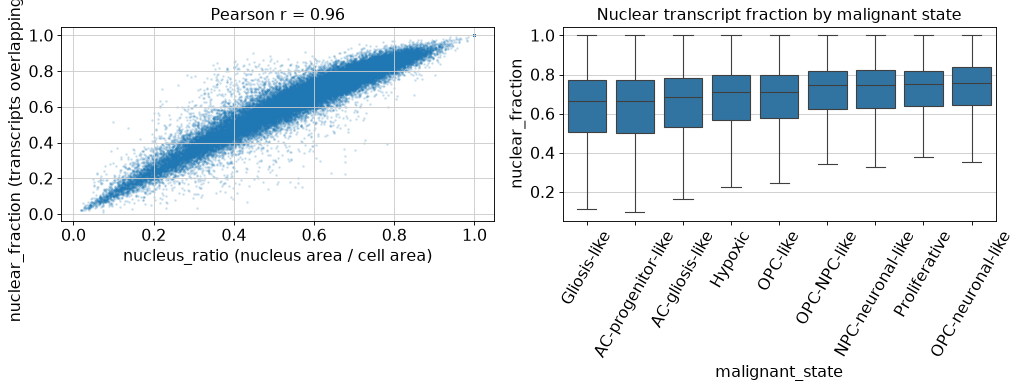

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(adata.obs["nucleus_ratio"], adata.obs["nuclear_fraction"], s=2, alpha=0.15)
axes[0].set_xlabel("nucleus_ratio (nucleus area / cell area)")
axes[0].set_ylabel("nuclear_fraction (transcripts overlapping nucleus)")
r = adata.obs[["nucleus_ratio", "nuclear_fraction"]].dropna().corr().iloc[0, 1]
axes[0].set_title(f"Pearson r = {r:.2f}")

order = adata.obs.groupby("malignant_state")["nuclear_fraction"].median().sort_values().index
sns.boxplot(data=adata.obs, x="malignant_state", y="nuclear_fraction", order=order, ax=axes[1], showfliers=False)
axes[1].tick_params(axis="x", rotation=60)
axes[1].set_title("Nuclear transcript fraction by malignant state")
plt.tight_layout()
plt.show()

🔬 **TASK 7.3:** Look at spillover *per gene* — which genes are most/least
nuclear-retained?

In [31]:
per_gene = (
    transcripts.groupby("feature_name")["overlaps_nucleus"]
    .agg(n="size", nuclear_fraction="mean")
    .query("n >= 200")
    .sort_values("nuclear_fraction")
)
print("Most cytoplasmic (lowest nuclear_fraction):")
print(per_gene.head(10))
print("\nMost nuclear-retained (highest nuclear_fraction):")
print(per_gene.tail(10))

Most cytoplasmic (lowest nuclear_fraction):
                  n  nuclear_fraction
feature_name                         
CHIT1           517          0.245648
FCGR1A          789          0.280101
FPR1            765          0.295425
FOLR2           743          0.297443
ITGB2          7366          0.297719
SIGLEC7         527          0.311195
TREM2          4024          0.314861
FCGR3A         1585          0.315457
MMP9          11144          0.317032
CD4            5540          0.320939

Most nuclear-retained (highest nuclear_fraction):
                  n  nuclear_fraction
feature_name                         
GSDMB         14806          0.923072
CATSPER2       2676          0.924141
YJEFN3        38309          0.924378
AGER           5018          0.924472
MST1          18234          0.926511
TOMM40         6170          0.929173
CRNDE          7499          0.929324
CYP2D6         6991          0.930768
SERPINI2        548          0.934307
STH            4500          0.

❓ **QUESTION:** A low nuclear-retention fraction for a gene could mean two very
different things: (1) **real subcellular biology** — that mRNA is genuinely exported and
translated in the cytoplasm (true for most mature mRNAs, especially membrane/secreted
proteins translated at the ER), or (2) **a segmentation/diffusion artifact** — transcripts
detected just outside the nucleus boundary due to optical/diffusion spillover rather than
true localization. How would you try to tell these apart using only this dataset (hint:
think about what gene *density* and *local cell crowding* would predict under each
explanation)?

🔬 **TASK 7.4:** Visualize spillover directly: a zoomed-in spatial scatter of
individual transcripts, colored by whether they overlap a nucleus, to see spillover at
cell borders by eye.

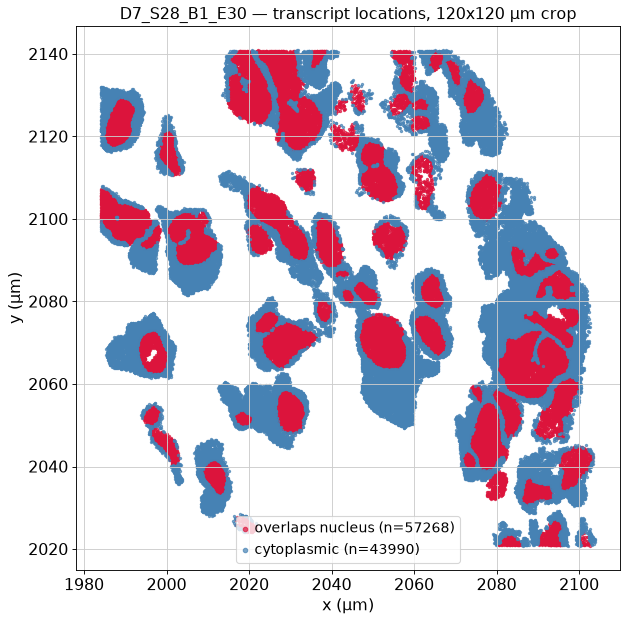

In [34]:
ref_sample = "D7_S28_B1_E30"
raw_tx = pq.read_table(
    RAW_DIRS[ref_sample] / "transcripts.parquet",
    columns=["x_location", "y_location", "overlaps_nucleus", "is_gene", "qv", "cell_id"],
    filters=[("is_gene", "=", True), ("qv", ">=", QV_CUTOFF)],
).to_pandas()
raw_tx = raw_tx[raw_tx["cell_id"] != "UNASSIGNED"]

# Crop a small, dense window for a legible zoom
xmid, ymid = raw_tx["x_location"].median(), raw_tx["y_location"].median()
half_width = 60.0  # microns
crop = raw_tx[
    raw_tx["x_location"].between(xmid - half_width, xmid + half_width)
    & raw_tx["y_location"].between(ymid - half_width, ymid + half_width)
]

fig, ax = plt.subplots(figsize=(8, 8))
for val, color, label in [(1, "crimson", "overlaps nucleus"), (0, "steelblue", "cytoplasmic")]:
    sub = crop[crop["overlaps_nucleus"] == val]
    ax.scatter(sub["x_location"], sub["y_location"], s=4, c=color, label=f"{label} (n={len(sub)})", alpha=0.7)
ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"{ref_sample} — transcript locations, {2*half_width:.0f}x{2*half_width:.0f} µm crop")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

🔬 **TASK 7.5:** Quantify the relationship between local cell density and apparent
cytoplasmic (non-nuclear) transcript fraction — denser regions should show more apparent
spillover, since cell boundaries are more ambiguous when cells are packed tightly.

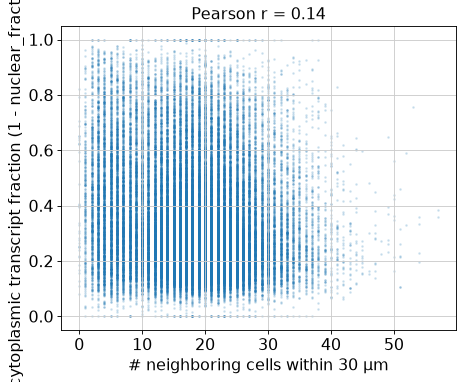

In [36]:
coords = adata.obsm["spatial"]
nn = NearestNeighbors(radius=30.0).fit(coords)
neighbor_counts = np.array([len(idx) - 1 for idx in nn.radius_neighbors(coords, return_distance=False)])
adata.obs["n_neighbors_30um"] = neighbor_counts

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(adata.obs["n_neighbors_30um"], 1 - adata.obs["nuclear_fraction"], s=2, alpha=0.15)
ax.set_xlabel("# neighboring cells within 30 µm")
ax.set_ylabel("cytoplasmic transcript fraction (1 - nuclear_fraction)")
r2 = adata.obs[["n_neighbors_30um", "nuclear_fraction"]].dropna().corr().iloc[0, 1]
ax.set_title(f"Pearson r = {r2:.2f}")
plt.tight_layout()
plt.show()

⚠️ **CHECKPOINT:** A positive correlation here (denser local neighborhoods → higher
cytoplasmic/apparent-spillover fraction) is the expected, biologically-motivated signature
of boundary-based transcript misassignment, distinct from genuine per-gene subcellular
localization (which would *not* depend on local cell density). If you see this signal,
you've independently rediscovered the exact problem motivating BASIS.

## 8. Write-up

🔬 **TASK 8.1:** In a few sentences, summarize:
1. How well your own marker-score cell typing agreed with the pre-existing `predictions`,
   and what that does/doesn't tell you about either pipeline.
2. How the organoid's malignant-state composition compares to real tumour tissue (Levels
   1-2), and what biological/technical reasons could explain the differences.
3. What you found in the nuclear-vs-cytoplasmic spillover analysis — is there a
   density-dependent component consistent with boundary misassignment, distinct from
   per-gene subcellular localization biology?

> Next: **Notebook 4** runs BASIS — a Bayesian transcript-reassignment algorithm — on one
> of these Xenium sections, and checks whether it actually reduces the spillover signal
> quantified here.